## Fichier d'analyse des résulats

In [13]:
import pandas as pd
import json

import matplotlib.pyplot as plt
from matplotlib import font_manager
import os


In [14]:
# Paramètres pour les graphiques
font_dir = "assets"

for file in os.listdir(font_dir):
    if file.endswith(".ttf"):
        font_manager.fontManager.addfont(os.path.join(font_dir, file))

plt.rcParams["font.family"] = "Marianne"
plt.rcParams.update({
    "font.family": "Marianne",

    "axes.titlesize": 16,
    "axes.titleweight": "bold",

    "figure.titlesize": 18,
    "figure.titleweight": "bold",

    "axes.labelsize": 12,
    "axes.labelweight": "regular",

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 10,
})

# Colors and styles for plotting
palette = {
    "Solaire":      "#d66b0d",
    "Hydro":        "#2672b0",
    "Onshore":       "#72cbb7",
    "Offshore":       "#4d8377",
    "H2_total":    "#e4a701",
    "STEP_charge": "#7a1616",
    "Fond":        "#ffffff",
    "STEP_decharge": "#ff0000",
    "Battery_charge": "#4B1063",
    "Battery_decharge": "#d126c9",
}

# Colonnes production (positives)
prod_cols = [
    'H2_total','Hydro','Solaire','Onshore','Offshore',
    'STEP_decharge','Battery_decharge'
]

# Colonnes charge
charge_cols = [
    'STEP_charge','Battery_charge'
]

In [15]:
df = pd.read_csv('results.csv', sep=';')
df.drop(columns=['t'], inplace=True)

json.load(open('parc_resultats.json', 'r'))

{'energie_totale_MWh': {'exces': 1191332.42,
  'defaillance': 0.0,
  'production_H2': 416966.35,
  'production_hydro': 88307.0},
 'cout_total_euros': 34222519123.01,
 'status': 'OPTIMAL',
 'capacites_MW': {'offshore': 0.0,
  'onshore': 0.0,
  'solar': 49603.03,
  'battery': 6461.52},
 'H2': {'unites_installees': [], 'nombre_installees': 0}}

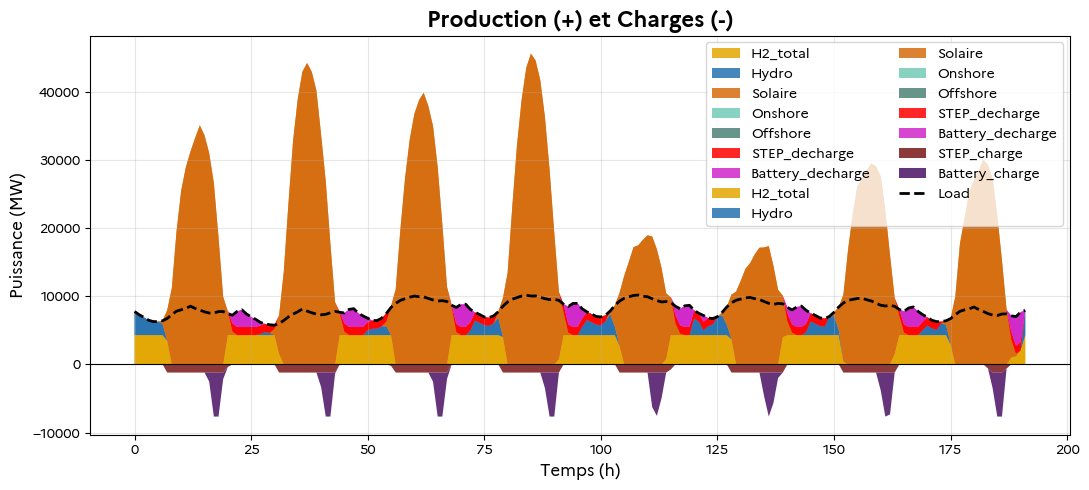

In [16]:
plt.figure(figsize=(11,5))

# --- STACK POSITIF ---
plt.stackplot(
    df.index,
    [df[c] for c in prod_cols],
    colors=[palette[c] for c in prod_cols],
    labels=prod_cols,
    alpha=0.85
)

# --- STACK POSITIF ---
plt.stackplot(
    df.index,
    [df[c] for c in prod_cols],
    colors=[palette[c] for c in prod_cols],
    labels=prod_cols,
    alpha=0.85
)

# --- STACK NEGATIF ---
plt.stackplot(
    df.index,
    [df[c] for c in charge_cols],   # ⚠️ on met en négatif
    colors=[palette[c] for c in charge_cols],
    labels=charge_cols,
    alpha=0.85
)

# Ligne zéro
plt.axhline(0, color="black", linewidth=0.8)

# Load
plt.plot(df.index, df['Load'], color="black", linestyle='--', linewidth=2, label="Load")

plt.title("Production (+) et Charges (-)")
plt.xlabel("Temps (h)")
plt.ylabel("Puissance (MW)")
plt.legend(ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

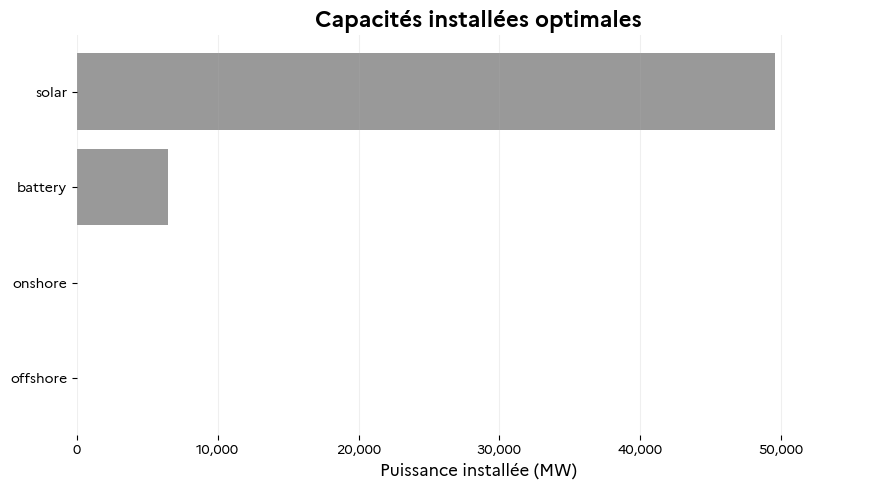

In [17]:
import json
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mtick
import os

# ------------------------
# Lecture du JSON
# ------------------------
with open("parc_resultats.json", "r") as f:
    parc = json.load(f)

data = parc["capacites_MW"]

# ------------------------
# Icônes associées
# ------------------------
icons = {
    "onshore": "assets/icons/eolien.png",
    "offshore": "assets/icons/eolien_offshore.png",
    "solar": "assets/icons/solaire.png",
    "battery": "assets/icons/batterie.png",
}

# ------------------------
# Fonction icône
# ------------------------
def add_icon(ax, x, y, icon_path, zoom=0.08):
    if not os.path.exists(icon_path):
        return
    img = plt.imread(icon_path)
    ab = AnnotationBbox(
        OffsetImage(img, zoom=zoom),
        (x, y),
        frameon=False,
        box_alignment=(0, 0.5)
    )
    ax.add_artist(ab)

# ------------------------
# Préparation données
# ------------------------
labels = list(data.keys())
values = list(data.values())

filtered = [(l, v) for l, v in zip(labels, values)]

if len(filtered) == 0:
    print("Aucune capacité installée.")
    exit()

labels, values = zip(*filtered)

# Tri croissant pour barres horizontales
labels, values = zip(*sorted(zip(labels, values), key=lambda t: t[1]))

# Couleurs simples (si palette existe sinon gris)
try:
    colors = [palette.get(k, "#999999") for k in labels]
except:
    colors = ["#4C72B0"] * len(labels)

# ------------------------
# Plot
# ------------------------
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(labels, values, color=colors)

ax.set_title("Capacités installées optimales", fontweight="bold")
ax.set_xlabel("Puissance installée (MW)")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

# Icônes
xmin, xmax = ax.get_xlim()
icon_x = xmin + (xmax - xmin) * 0.02

for y, label in enumerate(labels):
    add_icon(ax, icon_x, y, icons.get(label, ""), zoom=0.07)

ax.margins(x=0.15)
ax.grid(axis="x", alpha=0.2)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()